In [1]:
from typing import Annotated
import random
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage
from pydantic import BaseModel
import gradio as gr
from langchain_openai import ChatOpenAI

In [2]:
class State(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages()]

In [3]:
graph_builder = StateGraph(State)

In [4]:
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.3, max_tokens=100)
def llm_call(old_messages: State) -> State:
    response = llm.invoke(old_messages.messages)
    new_state = State(messages=old_messages.messages + [AIMessage(content=response.content)])
    return new_state

In [5]:
graph_builder.add_node("LLM_CALL", llm_call)

In [6]:
graph_builder.add_edge(START, "LLM_CALL")
graph_builder.add_edge("LLM_CALL", END)   

In [7]:
graph = graph_builder.compile()

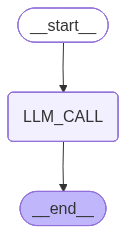

In [8]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
def chat(user_input: str, history):
    state = {"messages": [HumanMessage(content=user_input)]}
    result = graph.invoke(state)
    print(result)
    return result["messages"][-1].content

In [13]:
chat("What is the capital of France?", [])

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='79dadbe4-c0ed-4692-a7ed-4266fabe89f5'), AIMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={}, id='d4ba813e-18a8-4c94-917d-0a92a8e44f03', tool_calls=[], invalid_tool_calls=[])]}


'The capital of France is Paris.'